# 📌 Keras Tuner https://keras.io/keras_tuner/

## 🧠 ¿Qué es Keras Tuner?

**Keras Tuner** es una librería del ecosistema de TensorFlow diseñada para optimizar automáticamente los hiperparámetros de modelos construidos con Keras.

En términos simples:

> Es una herramienta que encuentra la mejor combinación de hiperparámetros sin que tengas que probarlos manualmente.

---

# 1️⃣ Parámetros vs Hiperparámetros

## 🔹 Parámetros
Son aprendidos automáticamente durante el entrenamiento:
- Pesos (weights)
- Bias

## 🔹 Hiperparámetros
Son definidos antes de entrenar el modelo:
- Número de capas
- Número de neuronas
- Learning rate
- Batch size
- Optimizador
- Dropout
- Número de épocas

Una mala elección puede causar:
- Overfitting
- Underfitting
- Bajo rendimiento

---

# 2️⃣ Problema que resuelve

Sin Keras Tuner, deberías probar manualmente múltiples combinaciones:

- 32, 64, 128 neuronas
- Adam o RMSprop
- Learning rate 0.01, 0.001, 0.0001

Este proceso es:
- Lento
- Poco eficiente
- No escalable

---

# 3️⃣ ¿Qué hace Keras Tuner?

Automatiza el proceso de búsqueda:

1. Define un espacio de búsqueda (search space)
2. Prueba diferentes combinaciones
3. Evalúa cada modelo
4. Devuelve la mejor configuración

---

# 4️⃣ Algoritmos de búsqueda disponibles

## 🔹 RandomSearch
Prueba combinaciones aleatorias.

Ventajas:
- Simple
- Útil en espacios grandes

Desventajas:
- No siempre encuentra el óptimo global

---

## 🔹 Hyperband
Descarta modelos malos rápidamente.

Ventajas:
- Muy eficiente
- Ideal para redes grandes

---

## 🔹 BayesianOptimization
Usa probabilidad para seleccionar mejores combinaciones.

Ventajas:
- Más inteligente
- Converge más rápido
- Ideal cuando entrenar es costoso

---

# INSTALAMOS KERAS TUNER

In [1]:
!pip install keras_tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 4.0 MB/s eta 0:00:00


# IMPORTAMOS LIBRERIAS

In [2]:
import tensorflow as tf
from tensorflow import keras
import keras_tuner as kt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

# CARGAMOS DATASET

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("adityakadiwal/water-potability")

print("Path to dataset files:", path)

100%|██████████| 251k/251k [00:00<00:00, 67.5MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/adityakadiwal/water-potability/versions/3


In [4]:
!ls /root/.cache/kagglehub/datasets/adityakadiwal/water-potability/versions/3

water_potability.csv


In [5]:
PATH_CSV = path + '/water_potability.csv'
df = pd.read_csv(PATH_CSV)
df

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
...,...,...,...,...,...,...,...,...,...,...
3271,4.668102,193.681735,47580.991603,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,1
3272,7.808856,193.553212,17329.802160,8.061362,NaN,392.449580,19.903225,NaN,2.798243,1
3273,9.419510,175.762646,33155.578218,7.350233,NaN,432.044783,11.039070,69.845400,3.298875,1
3274,5.126763,230.603758,11983.869376,6.303357,NaN,402.883113,11.168946,77.488213,4.708658,1


In [6]:
for col in ['ph','Sulfate','Trihalomethanes']:
  df[col].fillna(df[col].mean(),inplace=True)

df.isnull().sum()

/tmp/ipykernel_11192/1535639780.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(),inplace=True)


,0
ph,0
Hardness,0
Solids,0
Chloramines,0
Sulfate,0
Conductivity,0
Organic_carbon,0
Trihalomethanes,0
Turbidity,0
Potability,0


In [7]:
from sklearn.utils import resample

df_majority = df[df.Potability==0]
df_minority = df[df.Potability==1]

df_minority_oversampled = resample(df_minority,
                                 replace=True,     # sample with replacement
                                 n_samples=len(df_majority),    # to match majority class
                                 random_state=42) # reproducible results

df_balanced = pd.concat([df_majority, df_minority_oversampled])

df = df_balanced

print("Balanced dataset 'Potability' counts:")
print(df.Potability.value_counts())

Balanced dataset 'Potability' counts:
Potability
0    1998
1    1998
Name: count, dtype: int64


# SEPARACIÓN DATASET Y ESCALAMIENTO

In [8]:
X = df.drop(columns=["Potability"])
y = df["Potability"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# CONSTRUIMOS UN MODELO DE HIPERPARAMETROS AJUSTABLES

In [9]:
def build_model(hp):
  model = keras.Sequential()
  model.add(keras.layers.Dense(hp.Int("units1", min_value=8, max_value=64, step=8), activation="relu", input_shape=(X_train_scaled.shape[1],)))
  model.add(keras.layers.Dense(hp.Int("units2",min_value=8,max_value=64,step=8),activation='relu'))
  model.add(keras.layers.Dense(1,activation='sigmoid'))

  model.compile(
      optimizer=keras.optimizers.Adam(hp.Choice("learning_rate",[0.001,0.01,0.1])),
      loss='binary_crossentropy',
      metrics=['accuracy']
  )
  return model

# CREAMOS OBJETO DE KERAS TUNER

In [10]:
tuner = kt.Hyperband(
    build_model,
    objective='val_accuracy',
    max_epochs=20,
    factor=3,
    directory='kt_search',
    project_name='water_potability'
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
tuner.search(X_train_scaled,y_train,epochs=20,validation_data=(X_test_scaled,y_test))

Trial 30 Complete [00h 00m 12s]
val_accuracy: 0.5600000023841858

Best val_accuracy So Far: 0.7112500071525574
Total elapsed time: 00h 03m 16s


# MOSTRAMOS LOS MEJORES HIPERPARAMETROS

In [12]:
# Obtener el mejor modelo
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Mejor configuración: {best_hps.values}")

Mejor configuración: {'units1': 56, 'units2': 48, 'learning_rate': 0.001, 'tuner/epochs': 20, 'tuner/initial_epoch': 0, 'tuner/bracket': 0, 'tuner/round': 0}


# CREAMOS UN MODELO CON LOS MEJORES HIPERPARAMETROS

In [14]:
# Entrenar el mejor modelo encontrado
best_model = tuner.hypermodel.build(best_hps)
best_model.fit(X_train_scaled, y_train, epochs=20, validation_data=(X_test_scaled, y_test))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.5551 - loss: 0.6822 - val_accuracy: 0.5950 - val_loss: 0.6670
Epoch 2/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6176 - loss: 0.6486 - val_accuracy: 0.6300 - val_loss: 0.6401
Epoch 3/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6583 - loss: 0.6224 - val_accuracy: 0.6463 - val_loss: 0.6214
Epoch 4/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6668 - loss: 0.6042 - val_accuracy: 0.6388 - val_loss: 0.6133
Epoch 5/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6740 - loss: 0.5941 - val_accuracy: 0.6550 - val_loss: 0.6072
Epoch 6/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6827 - loss: 0.5858 - val_accuracy: 0.6600 - val_loss: 0.6037
Epoch 7/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6859 - loss: 0.5810 - val_accuracy: 0.6687 - val_loss: 0.6044
Epoch 8/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6818 - loss: 0.5773 - val_accuracy: 0

In [15]:
from sklearn.metrics import accuracy_score,confusion_matrix,ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

y_pred = best_model.predict(X_test_scaled)
y_pred = np.round(y_pred)

score = accuracy_score(y_test,y_pred)
print(f'el accuracy es {score}')

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
el accuracy es 0.67625


<Figure size 1100x1100 with 0 Axes>

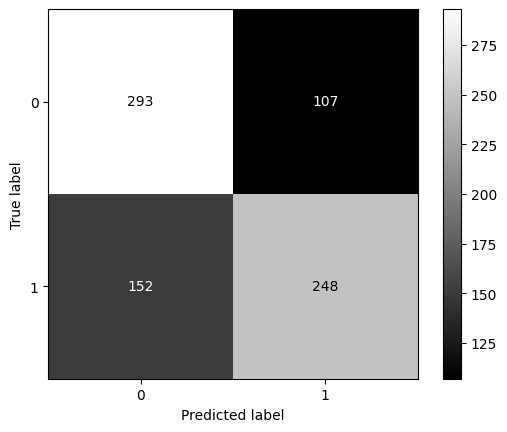

In [16]:
matrix = confusion_matrix(y_test,y_pred)
fig = plt.figure(figsize=(11,11))
cm = matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='gray')
plt.show()